# Train, Tune, And Scale Qwen3

Ready for a day in the life of a fictional frontier AI model developer? Today you will test a Qwen3 4B training step, find its memory limit, inspect a TPU profile, fine-tune an existing checkpoint, recover from a checkpoint, evaluate the result, and carry the pre-training state onto a larger GKE workload.

We use [MaxText](https://github.com/AI-Hypercomputer/maxtext), Google's JAX reference implementation for training large language models on TPUs. The longer MaxText commands live in [`scripts/final_project.py`](scripts/final_project.py) so each notebook cell can stay focused on one question. Open that file whenever you want to see the exact configs and commands.

Gemini and other AI assistants are welcome here. Ask them to explain an output, challenge your hypothesis, or help convert a dataset you care about. Treat their suggestions as ideas to test against your own measurements.

### Before You Run The First Cell

A **kernel** is the Python process that runs your notebook cells and remembers variables between them. Choose **Kernel > Change Kernel > ME344 MaxText**. This kernel uses the environment that has MaxText's post-training packages. Click the first code cell and press **Shift+Enter** to run it and move to the next cell.

You can run every required cell as written. Once a baseline works, feel free to change a prompt or one clearly marked parameter and see what happens.

## How this notebook was filled in

This is the course notebook for run `qanh-20260813t194806z` (2026-08-13 19:48Z to 20:28Z,
`tpu-student49`, v5litepod-8). The cells were not executed in Jupyter. They were driven
headlessly by `scripts_used/rerun_cells.py`, which makes the same calls with the same
arguments in the same order, because the session ran from a laptop rather than a browser.

The outputs below were put back afterwards by `build_assignment_notebook.py`:

- **stdout** is verbatim from `run_progress.log`, split by the `cell N START` / `cell N DONE`
  markers the driver wrote. Four of 1,324 output lines were clipped by the driver at 400
  characters and end mid-token.
- **figures** are the exact `.svg` / `.png` files the run wrote into
  `artifacts/qanh-20260813t194806z/`, reinserted where an interactive kernel would have
  rendered them. `MPLBACKEND=Agg` made every `plt.show()` a no-op, so they were saved to
  disk instead of displayed.
- **execution counts** are the real order the driver ran the cells in.

Two code cells carry no output:

- **Cell 2** (`CONFIG = project_config_from_env()`) ran first but prints nothing.
- **Cell 40** (`collect_reflections()` + `package()`) prompts for four answers on stdin, so
  the driver skipped it. It was run afterwards by `scripts_used/package_only.py` against the
  finished artifact directory, which installed `answers_final.md` and built
  `qanh-20260813t194806z.final.tar.gz` (`answers.md` + `systems_dashboard.png`), uploaded to
  `gs://me344-tpu-labs-west4/final_projects/qanh/submission/` at 20:32:45Z. That script's
  stdout was not captured.

**Cell 44** (`run_miniperf`) is marked optional in the assignment and never ran. The TPU VM
has since been deleted, so it cannot be run now.

Rebuild with `python build_assignment_notebook.py`. Restore the blank course notebook with
`git checkout dd6b98f -- me344_final_project/final_project.ipynb`.

In [1]:
import os
import sys
from pathlib import Path
START = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (START, *START.parents) if (path / "scripts/final_project.py").exists())
sys.path.insert(0, str(PROJECT_ROOT))
from scripts.final_project import project_config_from_env
CONFIG = project_config_from_env()

In [2]:
from scripts.final_project import FinalProject
project = FinalProject(CONFIG)

SUNet ID: qanh
Notebook results: /home/student49/me344-artifacts/qanh-20260813t194806z
Cloud output: gs://me344-tpu-labs-west4/final_projects/qanh/runs
Starting checkpoint: gs://me344-tpu-labs-west4/data/qwen3-4b-instruct-2507/0/items
Pinned MaxText commit: 17c7172720ca813b05e5ea248dedd78a0c64612e


## Did JAX Find Our TPU?

Before training, we need to know that Python is talking to the TPU rather than quietly using a CPU. A **backend** is the hardware platform JAX sends work to, a **process** is one running Python program, and a **device** is one TPU chip visible to JAX.

How many TPU devices should a v5e-8 report?

<details><summary>Check your answer</summary>

A v5e-8 TPU VM has eight TPU chips. Both environment checks should report the `tpu` backend, one JAX process, and eight devices. If your result differs, please seek help during office hours or post on Canvas for help before continuing.

</details>

In [3]:
device_reports = project.probe()

storage preflight: checkpoint read and output write/delete passed
pretrain {'python': '3.12.13', 'jax': '0.10.2', 'maxtext_commit': '17c7172720ca813b05e5ea248dedd78a0c64612e', 'backend': 'tpu', 'process_index': 0, 'process_count': 1, 'device_count': 8, 'local_device_count': 8, 'host_ram_bytes': 405698183168, 'devices': ['TPU_0(process=0,(0,0,0,0))', 'TPU_1(process=0,(1,0,0,0))', 'TPU_2(process=0,(0,1,0,0))', 'TPU_3(process=0,(1,1,0,0))', 'TPU_4(process=0,(0,2,0,
posttrain {'python': '3.12.13', 'jax': '0.11.0', 'maxtext_commit': '17c7172720ca813b05e5ea248dedd78a0c64612e', 'backend': 'tpu', 'process_index': 0, 'process_count': 1, 'device_count': 8, 'local_device_count': 8, 'host_ram_bytes': 405698183168, 'devices': ['TPU_0(process=0,(0,0,0,0))', 'TPU_1(process=0,(1,0,0,0))', 'TPU_2(process=0,(0,1,0,0))', 'TPU_3(process=0,(1,1,0,0))', 'TPU_4(process=0,(0,2,0
resolved model: {'emb_dim': 2560, 'num_decoder_layers': 36, 'num_query_heads': 32, 'num_kv_heads': 8, 'head_dim': 128, 'mlp_dim': 97

## Will Our First Training Step Fit?

An out-of-memory error can arrive after minutes of setup, so ML engineers compile a planned step before starting a long run. **Ahead-of-time compilation (AOT)** gives XLA the model, batch, sequence length, and TPU layout and asks for a per-chip buffer estimate. It does not execute an optimizer step. Each chip stores its live buffers in **high-bandwidth memory (HBM)**.

> **EXPECT AN OOM IN THIS CELL.** The deliberately bad data-parallel layout should run out of HBM. Seeing that OOM means the experiment worked and XLA protected us from starting a run that could not fit.

Our first estimate has four parts. A BF16 parameter checkpoint is roughly 2 bytes per parameter, or about 8 GB for 4B parameters. During training, MaxText keeps FP32 weights and two FP32 Adam moment arrays, about 48 GB of persistent state. A full FP32 gradient can add about 16 GB temporarily. Activations and compiler workspace depend on batch size, sequence length, and the compiled program. The plots use GiB, where 1 GiB is $2^{30}$ bytes, so these three estimates appear as roughly 7.5, 45, and 15 GiB.

The **global batch** is the number of examples used for one optimizer update. The **sequence length** is the maximum tokens in each example. Our first layout uses **tensor parallelism**, so all eight chips split each model layer. The controlled OOM uses **data parallelism**, which puts a complete model replica on every chip. If 64 GB of weights, optimizer state, and gradients split perfectly in the tensor-parallel layout, what rough amount lands on each chip before activations and workspace?

<details><summary>Check your estimate</summary>

About 8 GB, or 7.5 GiB, per chip. Real placement is not perfectly captured by that division, which is why we ask XLA next. Both compile tests use 1,024 tokens per step, but they arrange those tokens differently. The data-parallel case should still OOM because every chip receives the full model state. The validated tensor-parallel baseline uses global batch `2` and sequence length `512`. You may try another value after it compiles. Restore these two values if your experiment runs out of memory or you want to return to the course path.

</details>

/home/student49/me344_final_project/.venv-me344-posttrain/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[transformers] DeepseekV32Config got `key=rope_scaling` in kwargs but hasn't set it as attribute. For RoPE standardization you need to set `self.rope_parameters` in model's config. 
[transformers] DeepseekV4Config got `key=rope_scaling` in kwargs but hasn't set it as attribute. For RoPE standardization you need to set `self.rope_parameters` in model's config. 
EXPECTED RESULT: TP8 should compile, while the deliberately replicated DP8 layout should run out of HBM. That OOM confirms the capacity check works.
I0813 19:50:14.212329 139688836971648 max_utils.py:830] System Information: Jax Version: 0.10.2
I0813 19:50:14.212372 139688

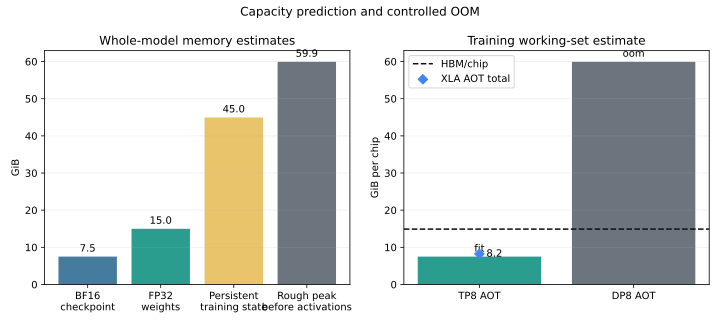

In [4]:
AOT_GLOBAL_BATCH = 2
AOT_SEQUENCE_LENGTH = 512
capacity_report = project.run_capacity_lab(
    global_batch=AOT_GLOBAL_BATCH,
    sequence_length=AOT_SEQUENCE_LENGTH,
)
project.plot_capacity()

## What Happens When We Run The Compiled Shape?

Now we execute the shape we just planned. MaxText first runs a tiny synthetic smoke test, then starts Qwen3 from random weights and trains for five steps on [C4 text](https://huggingface.co/datasets/allenai/c4). The C4 run saves a complete training checkpoint for the later GKE comparison.

The **loss** measures how surprised the model is by the correct next token. Lower loss is better when the data, tokenizer, and objective stay fixed. Five steps can confirm that the loop works and show the startup cost, but they cannot establish model quality.

Why should the first step take longer than the later steps?

<details><summary>Check your answer</summary>

The command still has startup work such as loading data and initializing arrays, and the first live execution may include compilation or cache setup. Later ordinary steps are a better throughput baseline. A step that saves a checkpoint or runs evaluation can also take longer because it performs extra work.

</details>

In [5]:
pretrain_checkpoint = project.run_baselines(
    smoke_steps=5,
    c4_steps=5,
    c4_sequence_length=AOT_SEQUENCE_LENGTH,
    c4_global_batch=AOT_GLOBAL_BATCH,
)

I0813 19:51:09.567130 139794417990784 max_utils.py:830] System Information: Jax Version: 0.10.2
I0813 19:51:09.567327 139794417990784 max_utils.py:831] System Information: Jaxlib Version: 0.10.2
I0813 19:51:09.567376 139794417990784 max_utils.py:832] System Information: Jax Backend: PJRT C API
Memstats: After params initialized:
I0813 19:51:18.398955 139794417990784 metric_logger.py:226] completed step: 0, seconds: 0.727, TFLOP/s/device: 0.319, Tokens/s/device: 2816.836, total_weights: 16384, loss: 10.872, lm_loss: 10.872, perplexity: 52703.133
I0813 19:51:18.505127 139794417990784 metric_logger.py:226] completed step: 1, seconds: 0.154, TFLOP/s/device: 1.508, Tokens/s/device: 13319.112, total_weights: 16384, loss: 10.866, lm_loss: 10.866, perplexity: 52362.266
I0813 19:51:18.512493 139794417990784 metric_logger.py:226] completed step: 2, seconds: 0.106, TFLOP/s/device: 2.185, Tokens/s/device: 19290.727, total_weights: 16384, loss: 10.860, lm_loss: 10.860, perplexity: 52070.148
I0813 1

## How Much Work Should One Step Hold?

The **global batch** is the number of training examples used for one optimizer update. The **sequence length** is the maximum number of tokens in each example. More tokens per step can improve hardware utilization, while activations and compiler workspace consume more HBM.

For each batch below, the helper runs AOT first and executes eight steps only when the compile fits. Predict where throughput will stop improving and where memory will run out. **You should see another OOM at the memory boundary. Finding that failed shape is a successful result.**

<details><summary>What the validated run found</summary>

At sequence length 256, throughput rose quickly through batch 32 and then mostly plateaued while memory continued to grow. Batch 512 was the first tested AOT OOM. Your numbers can vary slightly. You can later try sequence length 128 or 512 to see how a different tensor shape moves the boundary.

</details>

I0813 19:55:08.693644 140455457107072 max_utils.py:830] System Information: Jax Version: 0.10.2
I0813 19:55:08.693689 140455457107072 max_utils.py:831] System Information: Jaxlib Version: 0.10.2
I0813 19:55:08.693737 140455457107072 max_utils.py:832] System Information: Jax Backend: PJRT C API
Memory analysis: CompiledMemoryStats(generated_code_size_in_bytes=21217280, argument_size_in_bytes=6033895936, output_size_in_bytes=6033861120, alias_size_in_bytes=6033854976, temp_size_in_bytes=2799007744, host_generated_code_size_in_bytes=0, host_argument_size_in_bytes=0, host_output_size_in_bytes=0, host_alias_size_in_bytes=0, host_temp_size_in_bytes=0)
sweep-aot-gb4 finished in 0.5 minutes (exit 0).
I0813 19:55:38.320754 139639146966144 max_utils.py:830] System Information: Jax Version: 0.10.2
I0813 19:55:38.320916 139639146966144 max_utils.py:831] System Information: Jaxlib Version: 0.10.2
I0813 19:55:38.320970 139639146966144 max_utils.py:832] System Information: Jax Backend: PJRT C API
Mem

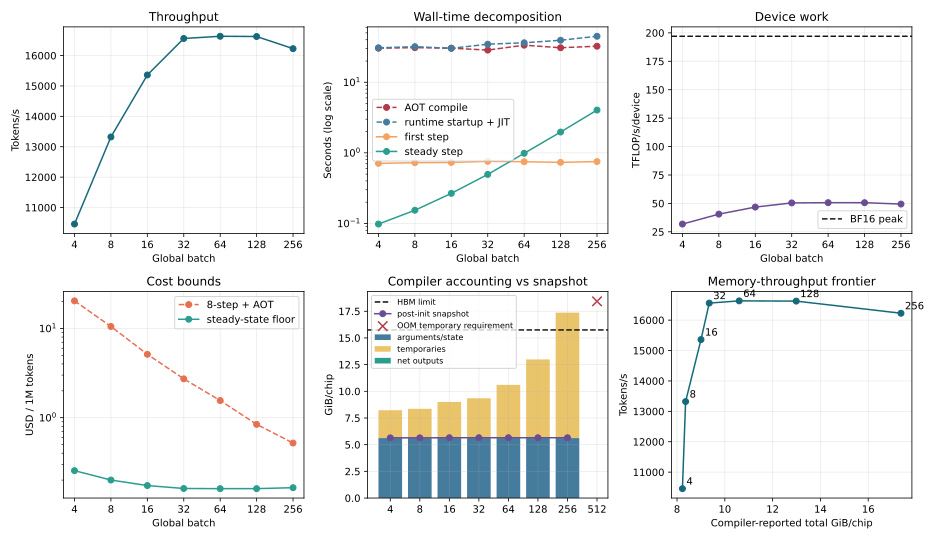

In [6]:
SWEEP_BATCHES = (4, 8, 16, 32, 64, 128, 256, 512)
SWEEP_SEQUENCE_LENGTH = 256
sweep_csv = project.run_sweep(
    global_batches=SWEEP_BATCHES,
    sequence_length=SWEEP_SEQUENCE_LENGTH,
    steps=8,
)
project.plot_sweep()

### How Much Hardware Headroom Remains?

A rough dense-transformer proxy uses about $6P$ floating-point operations per token. Comparing that work with the TPU's published BF16 peak gives us a ceiling, not a quality score. The comparison tells us whether systems tuning could still matter before we add more chips.

<details><summary>How to read the result</summary>

Being below the peak does not prove that the TPU is simply idle. Memory traffic, communication, operation mix, and compiler choices all contribute. The profile in the next section helps us inspect those possibilities.

</details>

{
  "reason": "A lower bound shows whether more tuning can matter; no real step can beat peak hardware.",
  "assumptions": [
    "Dense-transformer training is approximated as 6 * parameters * tokens FLOPs.",
    "All eight chips sustain the published 197 BF16 TFLOP/s peak with no communication or stalls.",
    "The bound is optimistic; measured/peak TFLOPs is a utilization proxy, not model FLOPs utilization."
  ],
  "cases": [
    {
      "global_batch": 4,
      "tokens_per_step": 1024,
      "approximate_training_flops": 24714043981824,
      "peak_compute_lower_bound_seconds": 0.015681499988467004,
      "measured_steady_step_seconds": 0.097925,
      "time_efficiency_percent": 16.013786048983413,
      "measured_peak_tflops_percent": 16.163369853041903
    },
    {
      "global_batch": 8,
      "tokens_per_step": 2048,
      "approximate_training_flops": 49428087963648,
      "peak_compute_lower_bound_seconds": 0.03136299997693401,
      "measured_steady_step_seconds": 0.15373124

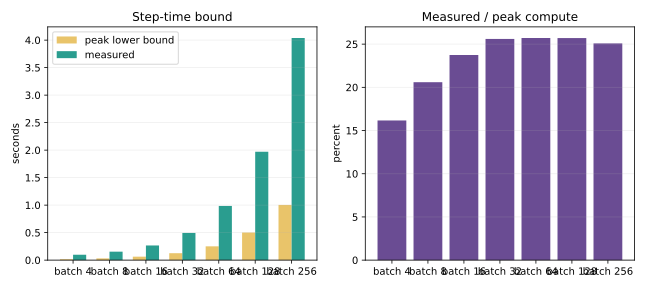

In [7]:
compute_bound = project.analyze_compute_bound()

## Where Does A Training Step Spend Its Time?

[XProf](https://openxla.org/xprof) records host work, TPU operations, memory traffic, and communication between chips. The helper profiles the smallest batch that came within 1% of the best measured throughput while keeping compiler-reported memory below 90% of HBM. Recording a trace adds work, so a profiled step can be slower than the same unprofiled step.

Before opening the profile, write down one guess: compute, HBM traffic, communication, or gaps between operations. The profile gives evidence for revising that guess.

<details><summary>What counts as an answer</summary>

There may be more than one limit. Name one visible piece of evidence, such as a long collective, an HBM-bound operation, a compute-bound operation, or a gap in the trace. Avoid diagnosing the run from utilization percentage alone.

</details>

In [8]:
project.capture_profile(
    sequence_length=SWEEP_SEQUENCE_LENGTH,
    steps=10,
    skip_steps=3,
    profile_steps=3,
)

Profiling global batch 32: the smallest shape within 1% of peak with a compiler-reported total below 90% of the HBM limit (59.4%).
I0813 20:04:14.088953 140184723160192 max_utils.py:830] System Information: Jax Version: 0.10.2
I0813 20:04:14.089168 140184723160192 max_utils.py:831] System Information: Jaxlib Version: 0.10.2
I0813 20:04:14.089218 140184723160192 max_utils.py:832] System Information: Jax Backend: PJRT C API
Memstats: After params initialized:
I0813 20:04:25.258369 140184723160192 metric_logger.py:226] completed step: 0, seconds: 0.752, TFLOP/s/device: 33.193, Tokens/s/device: 1362.604, total_weights: 8192, loss: 494.061, lm_loss: 494.061, perplexity: inf
I0813 20:04:25.753744 140184723160192 metric_logger.py:226] completed step: 1, seconds: 0.282, TFLOP/s/device: 88.530, Tokens/s/device: 3634.221, total_weights: 8192, loss: 494.061, lm_loss: 494.061, perplexity: inf
I0813 20:04:26.301099 140184723160192 metric_logger.py:226] completed step: 2, seconds: 0.323, TFLOP/s/dev

### Explore The Profile In XProf

Open a new Jupyter terminal on the TPU VM and copy the two lines printed immediately above. They already point at a local copy of your profile (copied there automatically during the profiling step), so XProf won't crash trying to read straight from Cloud Storage.

```bash
xprof --logdir=/home/YOUR_USER/me344-artifacts/YOUR_RUN_ID/xprof_profile/tensorboard --port=6006
```

Run that command, keep the terminal open, and visit `http://127.0.0.1:6006` on your laptop. The command printed by your cell contains your real local path; do not type the placeholder above.

<details><summary>Seeing SSH "Connection refused" messages, or XProf still says no profile data was found?</summary>

`Connection refused` in your SSH terminal just means XProf isn't running right now — rerun the `xprof` line printed above; you do not need to rebuild the tunnels.

If XProf still reports no profile data, the local copy step may have failed (a warning would have printed above the `xprof` command when the profiling cell ran). In that case fall back to serving directly from GCS:

```bash
xprof --logdir=gs://me344-tpu-labs-west4/final_projects/YOUR_SUNET/runs/me344-YOUR_SUNET-...-profile/tensorboard --port=6006
```

</details>

1. **Overview Page:** Find the profiled step time and bottleneck summary.
2. **Trace Viewer:** Open one `train` step. Treat navigation like a video game: use **W/S** to zoom and **A/D** to move through time. Look for TPU operations, communication collectives, and gaps.
3. **Roofline Analysis:** Select an operation and see whether it is closer to the HBM-bandwidth roof or compute roof.

Why might the traced steps or a checkpoint step be slower than nearby training steps? Profiling records extra events, while a checkpoint copies state to storage. Remember one trace observation for the final reflection, then stop XProf with **Ctrl+C**.

## What Should Our Fine-Tuning Data Teach?

We now switch from random-weight systems tests to the instructor's Qwen3 checkpoint. **Supervised fine-tuning (SFT)** gives the model a prompt and a desired answer, measures how surprising the desired answer is, and updates the model to make answers like it more likely.

[Banking77](https://huggingface.co/datasets/PolyAI/banking77) contains online-banking requests labeled with 77 customer-service intents ([paper](https://aclanthology.org/2020.nlp4convai-1.5/)). We use a 20-intent slice with 400 training examples because it is small enough for class and has an exact label we can score. The goal is to make Qwen3 return labels such as `pending_transfer` for a matching request.

The next cell prints 20 examples. Check whether each request matches its label and note labels that seem easy to confuse. This review catches data problems before they become model behavior.

<details><summary>What should a useful review find?</summary>

There is no required criticism. A useful answer identifies an ambiguous request, a pair of overlapping labels, or confirms that the sample follows the one-label task. The full public rows stay in the local run folder because the submission only needs your answers and dashboard.

</details>

In [9]:
dataset_report = project.prepare_data()



Data review (not copied into the submission):
01. Transfers can take up to one day to process before departing for the beneficiary accounts. Please confirm that you've entered your account details correctly. SE -> pending_transfer
02. Why are the things I bought earlier today still showing as pending? -> pending_card_payment
03. Why does my transfer say it is pending? -> pending_transfer
04. When did you send me my new card? -> card_arrival
05. Transfer unable to be completed, states 'declined' -> declined_transfer
06. I tried to make a transfer but it failed. will you tell me why? -> failed_transfer
07. I got less cash because of the exchange rate. -> wrong_exchange_rate_for_cash_withdrawal
08. Every ATM I visit is rejecting my card and I don't know why. There should be money on it. Can you check it to see if something is wrong or if I'm doing somethin -> declined_cash_withdrawal
09. Explain to me why a transfer would be declined. -> declined_transfer
10. Hi I am trying to transfer 

### Will A Sequence Length Of 256 Cut Off Examples?

Longer sequences preserve more text, but they increase activation memory and attention work. We tokenize the examples before training so we can see their actual lengths instead of guessing.

<details><summary>What the validated dataset showed</summary>

The longest selected example used 217 tokens, so a limit of 256 did not truncate one. Shorter examples still require padding because packing is disabled. If you use your own data, repeat this check rather than assuming 256 is enough.

</details>

{
  "reason": "Sequence length buys coverage but increases activation memory and padded compute.",
  "examples": 400,
  "sequence_length": 256,
  "mean_total_tokens": 162.0525,
  "p95_total_tokens": 187.04999999999995,
  "max_total_tokens": 217,
  "mean_completion_tokens": 6.65,
  "truncated_examples": 0,
  "truncated_percent": 0.0,
  "padded_token_utilization_percent": 63.3017578125,
  "padding_tokens_if_unpacked": 37579,
  "decision": "Shorten only if saved memory/compute is worth the measured truncation; packing changes this math."
}


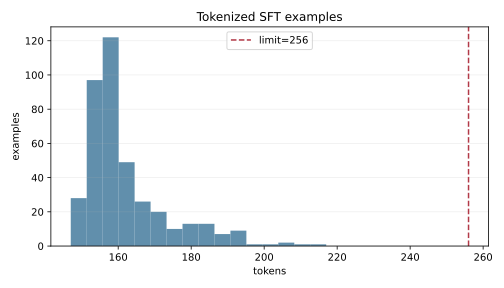

In [10]:
token_budget = project.analyze_token_budget(sequence_length=256)

## Fine-Tune The Model

We will run 200 SFT optimizer steps and check held-out loss every 25 steps. With 400 training examples and global batch 4, this is about two passes through the training set. Watch whether training and held-out loss fall together; held-out loss tells us whether the change also helps examples the model did not train on.

In [11]:
sft_checkpoint = project.run_sft(
    steps=200,
    global_batch=4,
    sequence_length=256,
    learning_rate=3e-6,
)

I0813 20:05:32.402182 139812568857728 max_utils.py:830] System Information: Jax Version: 0.11.0
I0813 20:05:32.402355 139812568857728 max_utils.py:831] System Information: Jaxlib Version: 0.11.0
I0813 20:05:32.402428 139812568857728 max_utils.py:832] System Information: Jax Backend: PJRT C API
I0813 20:06:26.877949 139812568857728 peft_trainer.py:840] Train step 0 eval loss: 0.805836 - eval perplexity: 2.238567
I0813 20:08:16.078794 139812568857728 peft_trainer.py:488] Train step 1 training loss: 0.696695  - training perplexity: 2.007108
Memstats: After params initialized:
I0813 20:08:33.290899 139812568857728 metric_logger.py:226] completed step: 1, seconds: 101.285, TFLOP/s/device: 0.031, Tokens/s/device: 1.264, total_weights: 53, loss: 0.697, lm_loss: 0.000, perplexity: 2.007
I0813 20:08:33.307932 139812568857728 peft_trainer.py:488] Train step 2 training loss: 1.450176  - training perplexity: 4.263864
I0813 20:08:33.314438 139812568857728 metric_logger.py:226] completed step: 2, se

## Can We Resume Without Starting Over?

A parameter-only checkpoint is enough for inference. Resuming the same Adam run also needs the optimizer moments and step number. The next cell restores the full step-200 state and runs steps 201 and 202. Step 200 remains available so we can undo this two-step recovery test.

<details><summary>What the validated loss curve taught us</summary>

Across our validation runs, held-out loss began near 0.8 and ended below 0.17 after 200 steps. The exact curve varied. This 20-example held-out set is a smoke test, so a longer run would use more evaluation data and preserve intermediate candidates instead of treating one curve as a release decision.

</details>

I0813 20:12:56.039800 140431264386176 max_utils.py:830] System Information: Jax Version: 0.11.0
I0813 20:12:56.039971 140431264386176 max_utils.py:831] System Information: Jaxlib Version: 0.11.0
I0813 20:12:56.040035 140431264386176 max_utils.py:832] System Information: Jax Backend: PJRT C API
I0813 20:13:48.069771 140431264386176 peft_trainer.py:488] Train step 201 training loss: 0.012250  - training perplexity: 1.012325
Memstats: After params initialized:
I0813 20:14:02.186103 140431264386176 metric_logger.py:226] completed step: 201, seconds: 19.622, TFLOP/s/device: 0.159, Tokens/s/device: 6.523, total_weights: 53, loss: 0.012, lm_loss: 0.000, perplexity: 1.012
I0813 20:15:57.860049 140431264386176 peft_trainer.py:748] Train loop finished in: 149.4095 seconds
I0813 20:15:58.138116 140431264386176 peft_trainer.py:488] Train step 202 training loss: 0.323556  - training perplexity: 1.382034
I0813 20:15:58.148617 140431264386176 metric_logger.py:226] completed step: 202, seconds: 130.06

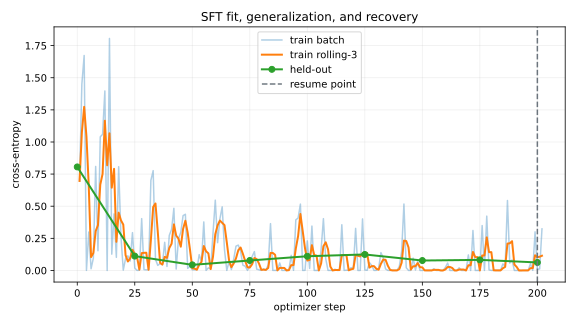

In [12]:
sft_checkpoint = project.resume_sft(extra_steps=2)

## How Is Reward Training Different From SFT?

SFT learns from a supplied answer. Reinforcement learning samples answers, scores them, and uses those scores to adjust what the model is likely to produce.

```text
SFT:   prompt + desired answer -> loss -> update
GRPO:  prompt -> four sampled answers -> rewards -> relative update
```

This is a separate post-training stage called **Group Relative Policy Optimization (GRPO)**, introduced in the [DeepSeekMath paper](https://arxiv.org/abs/2402.03300). Our shaped arithmetic reward gives 1.0 for an exact answer, up to 0.75 for following the requested format, and small credit for a numerical near miss. MaxText runs the experiment through its post-training integration.

What happens if all four sampled answers receive the same reward?

<details><summary>Check your answer</summary>

Their relative advantages are zero, so that group supplies little or no learning signal. We run 12 updates and evaluate all 16 held-out prompts. In the latest validation, 11 of 12 groups had reward variation, format compliance rose from 37.5% to 100%, and mean reward rose from 1.076 to 1.393. Exact answers moved from 11 of 16 to 10 of 16. The reward taught the easy formatting behavior while the accuracy guardrail regressed, so we would keep the earlier checkpoint and revise the reward or training recipe.

</details>



{
  "dataset_id": "openai/gsm8k train",
  "dataset_revision": "740312add88f781978c0658806c59bc2815b9866",
  "dataset_license": "MIT",
  "selection": "32 train + 16 held-out rows from 1024 scanned; 5-9 annotated arithmetic operations, prompt <=800 characters, seed 344",
  "student_provided": false,
  "task": "verifiable numeric reasoning",
  "train_examples": 32,
  "held_out_examples": 16,
  "schema": {
    "prompt": "string",
    "answer": "finite decimal string"
  },
  "reward": {
    "format": "0.75 full structure; 0.50 both sections; 0.25 answer tag; 0.10 partial reasoning tag",
    "exact": "1.0 exact numeric answer, tags optional",
    "closeness": "up to 0.10 for an incorrect near miss",
    "maximum": 1.75
  },
  "release_test_contamination": false,
  "raw_rows_in_submission": false,
  "reward_code": "rl_task.py",
  "reward_code_sha256": "34b181d8dfd8adb1bb4240714c8e5f5c2bc78e636289df498ca83b78f69e28ff"
}
I0813 20:16:37.579811 139708797660288 max_utils.py:830] System Informati

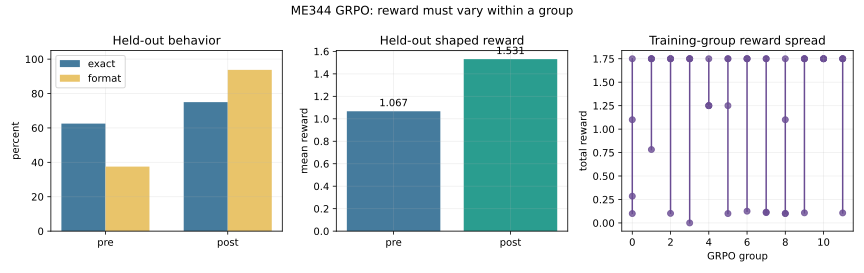

In [13]:
rl_summary = project.run_grpo(
    updates=12,
    generations=4,
)

## Did Fine-Tuning Help?

We now load the base and SFT checkpoints and run inference on untouched Banking77 requests plus GSM8K math prompts. Banking77 measures the skill we trained. GSM8K is a small retention check for an unrelated capability. The GRPO result remains separate because it trained on arithmetic rewards.

Before looking at the results, choose a guardrail that would make **more work** the responsible recommendation. Examples include no Banking77 gain, a clear math regression, broken output format, or unacceptable serving latency.

<details><summary>What the validated run found</summary>

The base checkpoint scored 70% Banking77 exact match and the SFT checkpoint scored 92.5%. GSM8K moved from 81.2% to 87.5% in this small sample. These are encouraging smoke-test results, not a complete release evaluation. If your formatting score rises while exact accuracy falls, report both: the model learned the format, but it did not improve on the full task.

</details>

In [14]:
release_evidence = project.run_evaluation_and_serving(benchmark_requests=8)

Evaluating base: loading gs://me344-tpu-labs-west4/data/qwen3-4b-instruct-2507/0/items
base server ready at 127.0.0.1:8000
base complete: Banking77 exact=70.0%, GSM8K exact=81.2%
Stopped the base inference server after 2.0 minutes.
Evaluating sft: loading gs://me344-tpu-labs-west4/final_projects/qanh/runs/me344-qanh-20260813t194806z-sft/checkpoints/202/model_params
sft server ready at 127.0.0.1:8000
sft complete: Banking77 exact=92.5%, GSM8K exact=87.5%
SFT changed Banking77 exact match by +22.5 points and format compliance by +0.0 points.
{
  "primary_suite": "PolyAI/banking77 test (40 untouched rows)",
  "retention_suite": "openai/gsm8k test[0:16]",
  "secondary_suite_role": "GSM8K is the SFT safety check and the separate GRPO target; Banking77 remains the startup product metric.",
  "models": [
    {
      "label": "base",
      "examples": 40,
      "exact_match_percent": 70.0,
      "format_compliance_percent": 100.0,
      "length_limited_percent": 0.0,
      "mean_completion_tok

### How Confident Are We In A Small Evaluation?

We need a range around an accuracy score because 30 correct answers out of 40 carry more sampling uncertainty than 300 out of 400. A **95% Wilson interval** estimates a plausible range for a success rate and behaves better than a simple normal approximation on small yes-or-no samples. The interval cannot repair a biased or unrepresentative test set. See [NIST's guide to binomial confidence bounds](https://doi.org/10.6028/NIST.TN.2119).

<details><summary>What should change as the test grows?</summary>

The point estimate can stay at 75%, while the interval becomes narrower. More representative examples give us a more precise estimate of performance on that population.

</details>

{
  "reason": "A point estimate without uncertainty can turn random prompt variation into a release claim.",
  "assumption": "Prompts are independent and representative; Wilson intervals do not fix biased data.",
  "target_margin_percentage_points": 10.0,
  "worst_case_samples_for_target_margin": 97,
  "models": [
    {
      "label": "base",
      "successes": 28,
      "trials": 40,
      "observed_percent": 70.0,
      "wilson_95_low_percent": 54.56968934567959,
      "wilson_95_high_percent": 81.9253290843047
    },
    {
      "label": "sft",
      "successes": 37,
      "trials": 40,
      "observed_percent": 92.5,
      "wilson_95_low_percent": 80.13546984090249,
      "wilson_95_high_percent": 97.41644432281419
    }
  ],
  "decision": "Treat this suite as a release smoke test; use a larger representative set for a real launch."
}


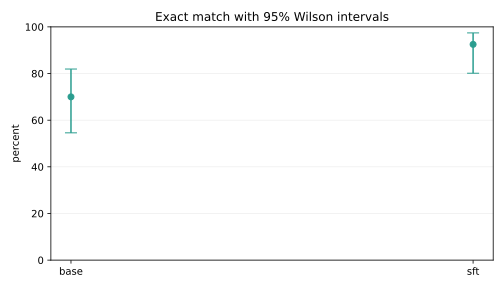

In [15]:
evaluation_bound = project.analyze_evaluation_uncertainty(target_margin=0.10)

## Optional: Chat With Your Model

The SFT checkpoint is still being served on port 8000. To try it, open a **Jupyter terminal on the TPU VM**, move to the assignment folder, and run:

```bash
uv run --no-project --python 3.12 --with gradio --with requests \
  python scripts/chat.py --base-url=http://127.0.0.1:8000
```

Open `http://127.0.0.1:7860` on your laptop. Try one Banking77 request and one unrelated prompt. Press **Ctrl+C** in the Jupyter terminal when you finish, or skip this section and continue.

In [16]:
project.stop_server()

Stopped the sft inference server after 2.1 minutes.


## Can The Same Checkpoint Run On More Workers?

The TPU VM pilot saved weights, Adam optimizer state, and the next step number. The next cell writes a small handoff file so every GKE run restores the same state.

We compare an 8-chip `2x4` baseline with two ways to arrange 16 chips: one `4x4` slice connected by the fast Inter-Chip Interconnect (ICI), and two `2x4` slices connected through the data-center network (DCN). **Strong scaling** holds global batch 256 fixed. **Weak scaling** uses batch 512 so each eight-chip model replica keeps the same amount of work. The repeated synthetic batch keeps input loading from changing between trials.

<details><summary>What are we looking for?</summary>

Doubling the chips gives an ideal 2x speedup. Real runs synchronize gradients and move tensors between workers, so they usually land below that line. Comparing one ICI slice with two DCN-connected slices shows whether the slower network changes the result even when the chip count and training configuration stay fixed.

</details>

In [17]:
scale_handoff = project.prepare_scale_handoff()

Checkpoint: gs://me344-tpu-labs-west4/final_projects/qanh/runs/me344-qanh-20260813t194806z-c4/checkpoints/4/items
GKE handoff: gs://me344-tpu-labs-west4/final_projects/qanh/scaling/handoff.json


### Run The GKE Comparison

> **PAUSE HERE. KEEP JUPYTER, THE TPU VM, AND YOUR FIRST SSH TERMINAL RUNNING.**

Open a second connection to your Stanford node and follow **Scale Across TPU Workers** in the README. GKE will run the 8-chip baseline, one 16-chip ICI slice, and two 8-chip DCN slices. Return here after `baseline.json`, `ici_strong.json`, `ici_weak.json`, `strong.json`, and `weak.json` appear in your course bucket folder.

{
  "baseline": {
    "assignment_version": "2026.08.02.2",
    "checkpoint_maxtext_git_sha": "17c7172720ca813b05e5ea248dedd78a0c64612e",
    "runtime_maxtext_git_sha": "07a3264e056c8d57abf0e00ab567d1f074a52233",
    "student_id": "qanh",
    "mode": "baseline",
    "slices": 1,
    "workers": 1,
    "nodes_per_slice": 1,
    "chips_per_worker": 8,
    "chips": 8,
    "fabric": "ICI",
    "topology": "2x4",
    "global_batch": 256,
    "sequence_length": 256,
    "tokens_per_step": 65536,
    "steady_steps": 8,
    "source_checkpoint": "gs://me344-tpu-labs-west4/final_projects/qanh/runs/me344-qanh-20260810t005140z-c4/checkpoints/4/items",
    "source_next_step": 5,
    "command_wall_seconds": 150.425448849,
    "first_step_seconds": 17.727698,
    "steady_step_seconds": 4.045448125,
    "tokens_per_second": 16199.93626714822,
    "tokens_per_second_per_chip": 2024.9920333935274
  },
  "ici_strong": {
    "assignment_version": "2026.08.02.2",
    "checkpoint_maxtext_git_sha": "17c717272

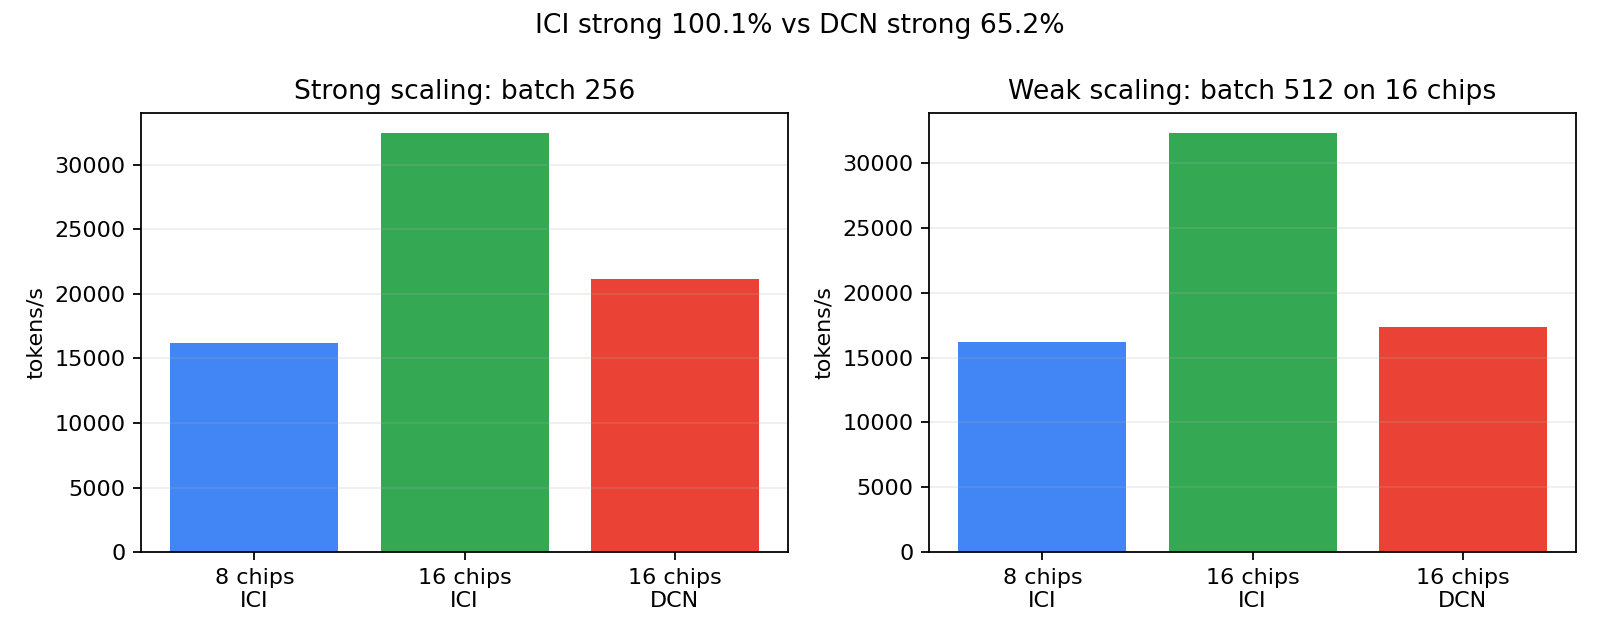

In [18]:
scale_report = project.collect_scale_results()

## What Would You Recommend?

The dashboard combines memory, throughput, scaling, loss, evaluation, serving, and cost evidence. A **systems win** finishes equivalent work faster or uses less memory. An **ML win** reaches better held-out quality without violating a retention or serving requirement. A release decision needs both kinds of evidence.

W&B records the same metrics in offline mode, so no account is required.

wandb: Tracking run with wandb version 0.28.2
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /home/student49/me344-artifacts/qanh-20260813t194806z/wandb/offline-run-20260813_202751-lw2h3uci
wandb: View this run in the terminal with `wandb leet`
wandb: WARNING URL not available in offline run
wandb: 
wandb: Run summary:
wandb:        bounds/best_peak_compute_percent 25.71202
wandb:       bounds/first_aot_oom_global_batch 512
wandb:     bounds/largest_aot_fit_global_batch 256
wandb: bounds/recommended_profile_global_batch 32
wandb:         bounds/release_samples_for_10pp 97
wandb:        bounds/token_utilization_percent 63.30176
wandb:       bounds/truncated_examples_percent 0
wandb:        release/base_exact_match_percent 70
wandb:             release/base_format_percent 100
wandb:     release/base_length_limited_percent 0
wandb:                                     +47 ...

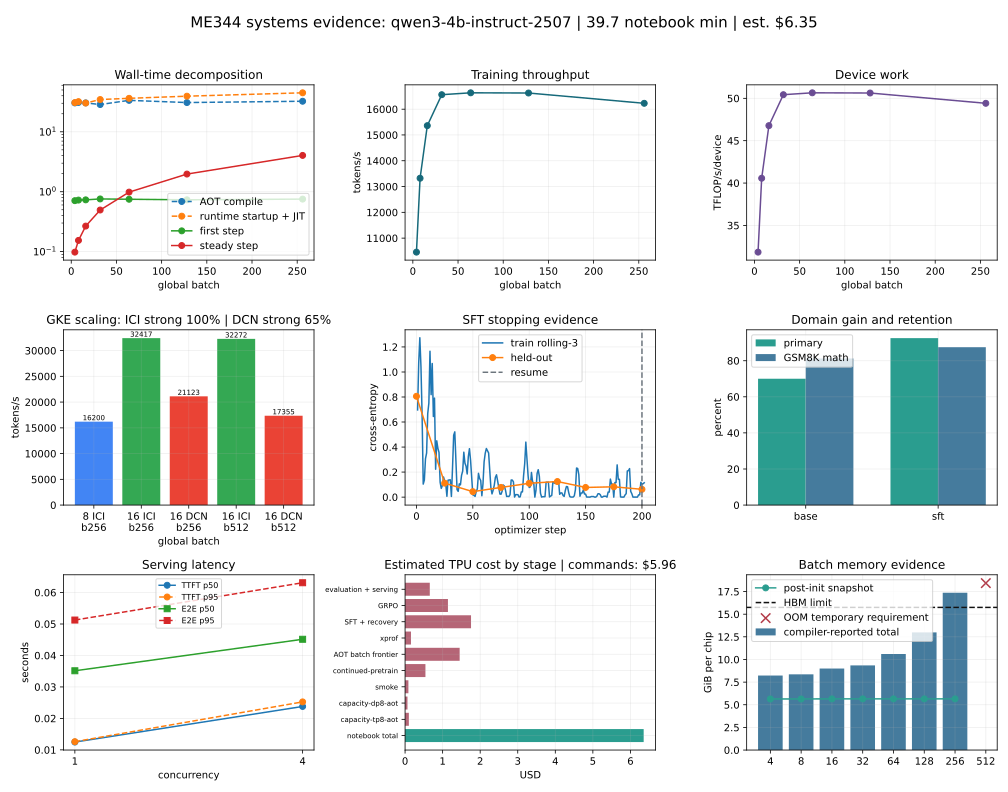

In [19]:
project.build_dashboard()
wandb_run = project.log_wandb()

## Write Four Answers And Package Your Work

The next cell asks four one-sentence questions, writes `answers.md`, packages it with `systems_dashboard.png`, and uploads the archive. Keep the TPU VM running until the upload succeeds. Then return to the README to verify the upload, delete the TPU VM, and download your Canvas submission.

In [20]:
project.collect_reflections()
final_archive = project.package()

## Required Work Complete

You planned a training step before running it, found a memory boundary, used XProf, trained and recovered a checkpoint, evaluated behavior, served the result, and compared ICI and DCN scaling.

Everything below is optional.

## Optional: What Would Your Data Teach?

Choose 50 to 500 examples from a subject you care about. Gemini or another AI agent can help convert rows into `{"input": "request", "output": "response"}` or chat `messages`, propose a held-out split, and suggest a metric. Review the converted rows yourself because formatting errors and invented labels become training targets.

On the TPU VM, validate the file and set these variables **before launching a new Jupyter server**:

```bash
python scripts/prepare_sft_jsonl.py my_data.jsonl /tmp/my_data.jsonl \
  --report /tmp/my_data_report.json
export ME344_DATASET=local
export ME344_LOCAL_JSONL=/tmp/my_data.jsonl
```

Then rerun the data, token-budget, SFT, and evaluation sections with a metric that matches your task.

## Optional: Can You Make The Same Work Faster?

[MLPerf Training](https://mlcommons.org/benchmarks/training/) compares systems by measuring wall time to a fixed quality target. Our small **MiniPerf** exercise borrows the controlled-comparison idea, but it is a course experiment and not an official MLPerf result.

Set `ME344_RUN_MINIPERF=1` before launching a new Jupyter server. The next cell searches the AOT memory boundary, then compares tensor parallelism, fully sharded data parallelism (FSDP), and activation rematerialization while holding the model, tokens, and correctness gate fixed. Before it runs, predict which of TP8, TP4+FSDP2, or FSDP8 will be fastest and which will use the least memory. Faster equivalent work is a systems win. Better held-out loss is an ML win. For a convergence-style extension, keep the model and data fixed and compare wall time to the same held-out-loss target.

<details><summary>What should stay fixed?</summary>

Keep the model, batch, sequence length, number of measured steps, data, seed, and correctness tolerance fixed when comparing systems changes. Otherwise a faster number may represent less or different work.

</details>

In [ ]:
miniperf = project.run_miniperf(
    enabled=os.environ.get("ME344_RUN_MINIPERF", "0") == "1",
)